## OH Time History Plot (0 to 0.5 ms)

/tmp/ipykernel_2321428/913598146.py:15: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasConstPressureReactor(gas, energy="on")
/tmp/ipykernel_2321428/913598146.py:25: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  y_sim[i] = reactor.thermo.X[oh_idx] * 1e6


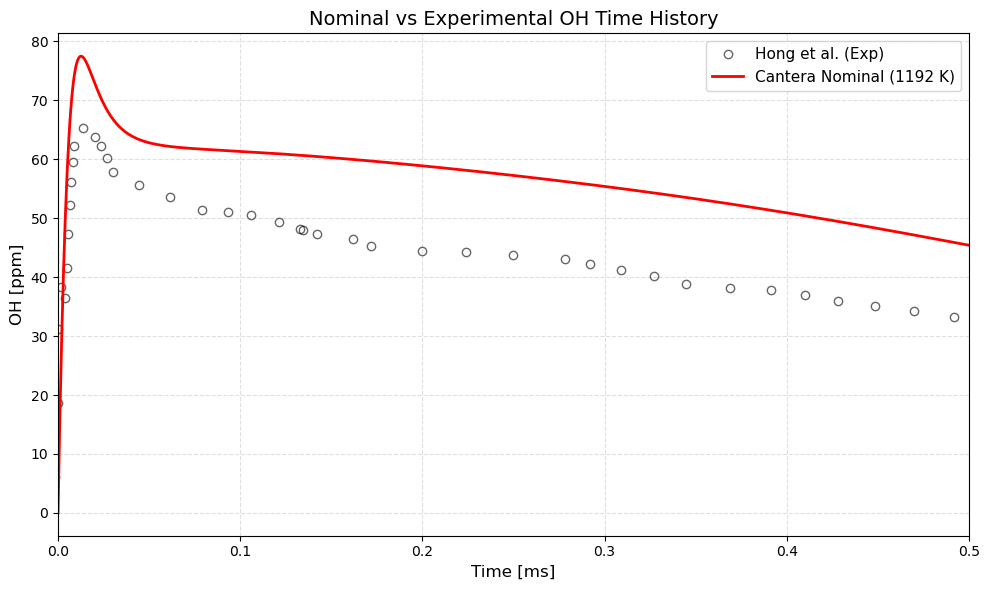

In [1]:
import pandas as pd
import cantera as ct
import numpy as np
import matplotlib.pyplot as plt

# Load experimental data
df = pd.read_csv("hong_1192K_oh.csv", skipinitialspace=True)
t_exp = df["Time [ms]"].values
y_exp = df["[OH] ppm"].values

# Set up Cantera simulation (1192 K nominal)
YAML_FILE = "chem_cti_toy_model_og.yaml"
gas = ct.Solution(YAML_FILE)
gas.TPX = 1192, 1.95 * ct.one_atm, {"H2O2": 2216e-6, "H2O": 1364e-6, "O2": 682e-6, "AR": 1.0 - (2216 + 1364 + 682) * 1e-6}
reactor = ct.IdealGasConstPressureReactor(gas, energy="on")
net = ct.ReactorNet([reactor])

# Simulate up to 0.5 ms
t_sim = np.linspace(0, 0.5e-3, 1000)
oh_idx = gas.species_index("OH")
y_sim = np.zeros(len(t_sim))
for i, t in enumerate(t_sim):
    if t > 0:
        net.advance(t)
    y_sim[i] = reactor.thermo.X[oh_idx] * 1e6

# Plot
plt.figure(figsize=(10, 6))
plt.plot(t_exp, y_exp, "ko", mfc="none", alpha=0.6, label="Hong et al. (Exp)")
plt.plot(t_sim * 1e3, y_sim, "r-", lw=2, label="Cantera Nominal (1192 K)")
plt.xlim(0, 0.5)
plt.xlabel("Time [ms]", fontsize=12)
plt.ylabel("OH [ppm]", fontsize=12)
plt.title("Nominal vs Experimental OH Time History", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, ls="--", alpha=0.4)
plt.tight_layout()
plt.show()
